<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 이미지


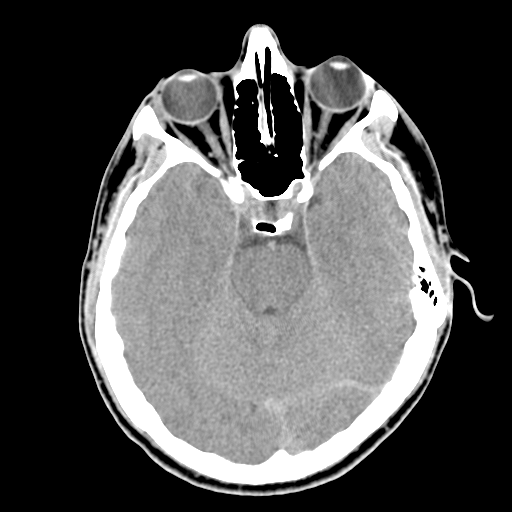

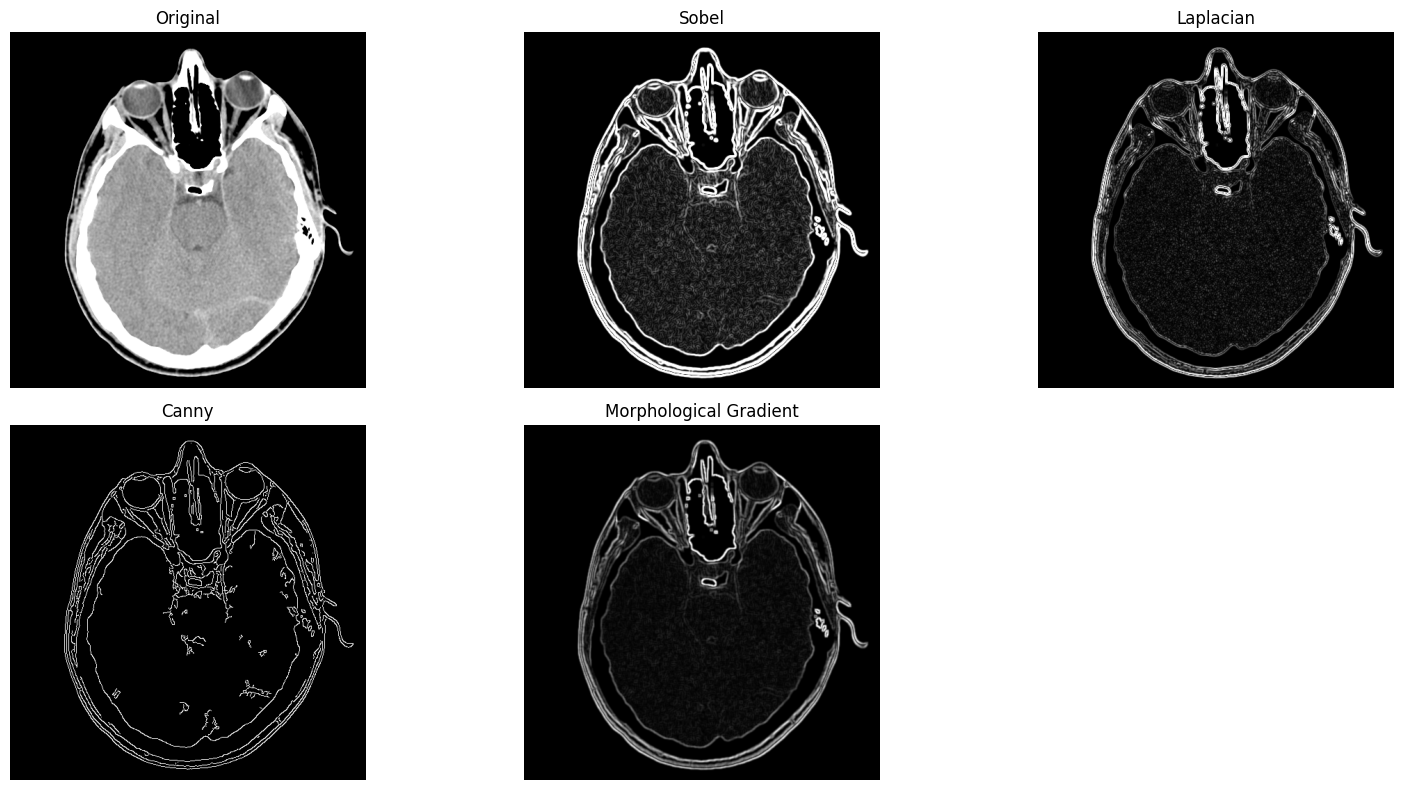

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# -------------------------------
# 1) 이미지 업로드
# -------------------------------
img = cv2.imread('/content/Fig0939(a)(headCT-Vandy).tif', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("이미지를 불러오지 못했습니다.")

print("원본 이미지")
cv2_imshow(img)

# -------------------------------
# 2) 전처리: 약한 블러
# -------------------------------
blur = cv2.GaussianBlur(img, (3, 3), 0)

# -------------------------------
# 3) Sobel
# -------------------------------
sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = cv2.convertScaleAbs(sobel_mag)

# -------------------------------
# 4) Laplacian
# -------------------------------
laplacian = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# -------------------------------
# 5) Canny
# -------------------------------
canny = cv2.Canny(blur, 50, 150)

# -------------------------------
# 6) Morphological Gradient
# -------------------------------
kernel = np.ones((3, 3), np.uint8)
morph_grad = cv2.morphologyEx(blur, cv2.MORPH_GRADIENT, kernel)

# -------------------------------
# 7) 출력
# -------------------------------
titles = [
    'Original',
    'Sobel',
    'Laplacian',
    'Canny',
    'Morphological Gradient'
]

images = [
    img,
    sobel_mag,
    laplacian_abs,
    canny,
    morph_grad
]

plt.figure(figsize=(16, 8))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()